#CSL7870: Learning on Graphs

#TASK-10

# Anuj Rajan Lalla

#B22AI061

# Observation tables printed here, journaled in report with further inference

# Imports

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from matplotlib.patches import Patch
from collections import Counter


# Seeding

In [ ]:
random.seed(0)
np.random.seed(0)


# Loading Karate club graph

In [ ]:
G = nx.karate_club_graph()

# For further analysis, I am coloring nodes by their labels

## Helps in seeing in how many hops can a node reach to the opposite class it's starting from , motivates further investigation which is journaled in report

In [ ]:
clubs = sorted({G.nodes[n].get('club','') for n in G.nodes()})
color_map = {clubs[0]: "#1f77b4", clubs[1]: "#2ca02c"} if len(clubs) >= 2 else {clubs[0]: "#1f77b4"}

# Helpers

## Builds the cycle-free, L-hop BFS tree rooted at root, and a level_map giving hop distance for every included node.

In [ ]:
def bfs_tree_using_nx(G, root, depth):
    D = nx.bfs_tree(G, root, depth_limit=depth)
    T = nx.Graph(D)
    level_map = dict(nx.shortest_path_length(T, source=root))
    return T, level_map


## computes 2D positions so all nodes at hop d share a row

In [ ]:
def tree_pos_by_level(level_map, x_spacing=1.0, y_spacing=1.4):
    inv = defaultdict(list)
    for n, lv in level_map.items():
        inv[lv].append(n)
    pos = {}
    for lv in sorted(inv.keys()):
        nodes = inv[lv]
        k = len(nodes)
        if k == 1:
            xs = [0.0]
        else:
            xs = np.linspace(- (k-1)/2.0 * x_spacing, (k-1)/2.0 * x_spacing, k)
        y = -lv * y_spacing
        for n, x in zip(nodes, xs):
            pos[n] = (float(x), float(y))
    return pos

## To improve plotting

In [ ]:
def _unclipped(art):
    if art is None: return
    if hasattr(art, "set_clip_on"):
        art.set_clip_on(False)
    elif isinstance(art, dict):
        for a in art.values(): _unclipped(a)
    elif isinstance(art, (list, tuple)):
        for a in art: _unclipped(a)


## draws a single root’s BFS tree on a given axis and returns the metrics

In [ ]:
def _draw_tree(ax, root, depth=2, x_spacing=1.0, y_spacing=1.4,
               base_node_size=220, root_scale=1.25):
    T, level_map = bfs_tree_using_nx(G, root, depth)
    pos = tree_pos_by_level(level_map, x_spacing, y_spacing)

    nodes_k = set(level_map.keys())
    induced = G.subgraph(nodes_k)
    removed = induced.number_of_edges() - T.number_of_edges()
    triangles = sum(nx.triangles(induced).values()) // 3
    clust = nx.average_clustering(induced) if induced.number_of_nodes() else 0.0

    e = nx.draw_networkx_edges(T, pos, ax=ax, width=1.2, edge_color='#333333', alpha=0.95)
    _unclipped(e)

    node_list = list(T.nodes())
    node_colors = [color_map.get(G.nodes[n].get('club',''), "#888888") for n in node_list]
    ncoll = nx.draw_networkx_nodes(T, pos, nodelist=node_list, node_color=node_colors,
                                   node_size=base_node_size, edgecolors='black', linewidths=0.8, ax=ax)
    _unclipped(ncoll)

    if root in pos:
        rcoll = nx.draw_networkx_nodes(
            T, pos, nodelist=[root],
            node_color=[color_map.get(G.nodes[root].get('club',''), "#888888")],
            node_size=base_node_size*root_scale, edgecolors='red', linewidths=2.0, ax=ax
        )
        _unclipped(rcoll)

    labels = {n: str(n) for n in node_list}
    txt = nx.draw_networkx_labels(T, pos, labels=labels, font_size=8,
                                  font_weight='bold', font_color='white', ax=ax)
    _unclipped(txt)

    if pos:
        xs, ys = zip(*pos.values())
        pad_x, pad_y = max(1.2*x_spacing, 0.6), max(1.2*y_spacing, 0.6)
        ax.set_xlim(min(xs)-pad_x, max(xs)+pad_x)
        ax.set_ylim(min(ys)-pad_y, max(ys)+pad_y)

    ax.axis('off')
    ax.set_title(f"node {root} (T={T.number_of_nodes()})", fontsize=10)

    return (T.number_of_nodes(), induced.number_of_nodes(), removed, triangles, round(clust,3))

## Experiment 1

### At the end of the output there's the tree stats quantify what the 2-hop drawings suggest (size, redundancy, clustering).

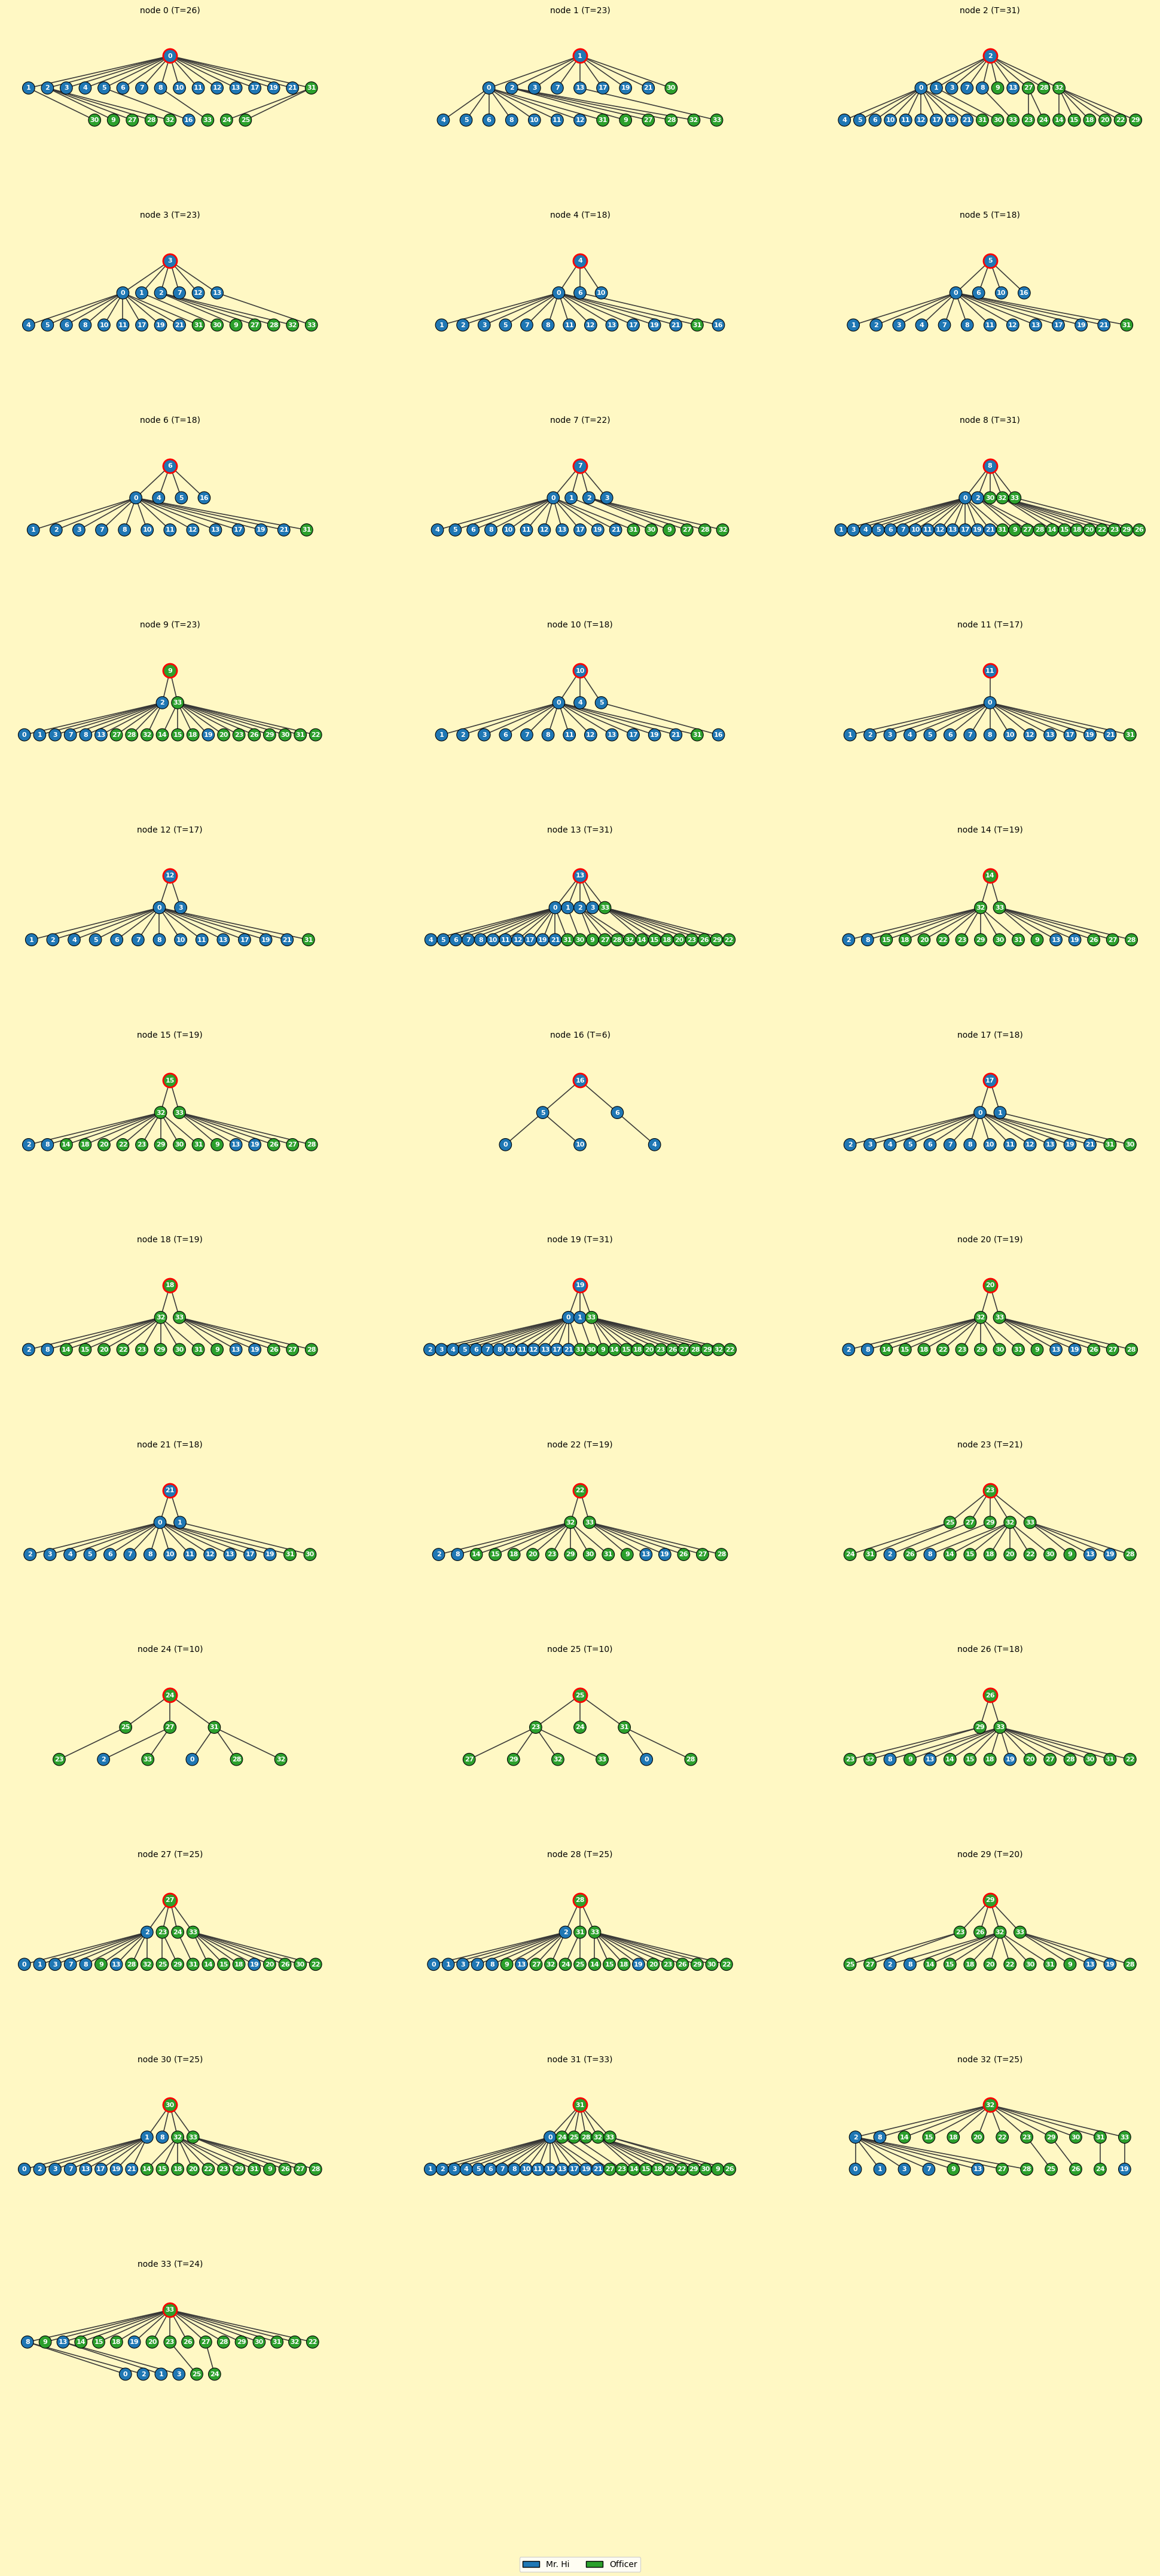

node | Tnodes | induced | removed | triangles | avg_clust
 0   |     26 |      26 |      34 |        34 | 0.506
 1   |     23 |      23 |      31 |        32 | 0.491
 2   |     31 |      31 |      41 |        42 | 0.570
 3   |     23 |      23 |      31 |        32 | 0.491
 4   |     18 |      18 |      19 |        26 | 0.680
 5   |     18 |      18 |      19 |        26 | 0.680
 6   |     18 |      18 |      19 |        26 | 0.680
 7   |     22 |      22 |      23 |        27 | 0.510
 8   |     31 |      31 |      41 |        43 | 0.601
 9   |     23 |      23 |      34 |        36 | 0.591
10   |     18 |      18 |      19 |        26 | 0.680
11   |     17 |      17 |      18 |        25 | 0.681
12   |     17 |      17 |      18 |        25 | 0.681
13   |     31 |      31 |      41 |        43 | 0.601
14   |     19 |      19 |      20 |        18 | 0.564
15   |     19 |      19 |      20 |        18 | 0.564
16   |      6 |       6 |       5 |         5 | 0.667
17   |     18 |      18 

In [ ]:
depth = 2
nrows, ncols = 12, 3
fig_w, fig_h = 20, 45
ax_face = "#fffde7"
fig_face = "#fff8c4"

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
fig.patch.set_facecolor(fig_face)
axes = axes.flatten()

summary = []
for i, node in enumerate(sorted(G.nodes())):
    ax = axes[i]
    ax.set_facecolor(ax_face)
    for s in ax.spines.values():
        s.set_visible(True); s.set_edgecolor("#e0e0e0"); s.set_linewidth(1.0)
    metrics = _draw_tree(ax, node, depth=depth, x_spacing=1.0, y_spacing=1.4,
                         base_node_size=220, root_scale=1.25)
    summary.append((node,)+metrics)

for j in range(len(G), nrows*ncols):
    axes[j].axis('off')

legend_items = [Patch(facecolor=color_map[c], edgecolor='black', label=c) for c in color_map]
fig.legend(handles=legend_items, loc='lower center', ncol=len(legend_items), frameon=True)
plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.06, hspace=0.45, wspace=0.25)
plt.show()

print("node | Tnodes | induced | removed | triangles | avg_clust")
for r in summary:
    print(f"{r[0]:2d}   | {r[1]:6d} | {r[2]:7d} | {r[3]:7d} | {r[4]:9d} | {r[5]:.3f}")

## Some more tables for journaling

### The hop table makes class-boundary proximity explicit per node.

In [ ]:
def club(n): return G.nodes[n]['club']

def hop_sets(n, k=2):
    d = nx.single_source_shortest_path_length(G, n, cutoff=k)
    L1 = {u for u,dist in d.items() if dist==1}
    L2 = {u for u,dist in d.items() if dist==2}
    return L1, L2

meta = {}
for n in sorted(G.nodes()):
    L1, L2 = hop_sets(n, 2)
    c = club(n)
    opp1 = sum(club(u)!=c for u in L1)
    opp2 = sum(club(u)!=c for u in L2)
    deg  = len(L1)
    minhop_opp = 1 if opp1>0 else (2 if opp2>0 else 3)
    meta[n] = dict(
        deg=deg, opp1=opp1, opp2=opp2,
        bndry_idx=(opp1/deg if deg else 0.0),
        L1_opp_frac=(opp1/len(L1) if L1 else 0.0),
        L2_opp_frac=(opp2/len(L2) if L2 else 0.0),
        minhop_opp=minhop_opp,
    )

print("node | club        | deg | opp1 | opp2 | bndry_idx | L1_opp | L2_opp | minhop_opp")
for n in sorted(meta):
    m = meta[n]
    print(f"{n:>3} | {club(n):<11} | {m['deg']:>3} | {m['opp1']:>4} | {m['opp2']:>4} | "
          f"{m['bndry_idx']:.2f}     | {m['L1_opp_frac']:.2f}  | {m['L2_opp_frac']:.2f}  | {m['minhop_opp']}")
# quick tallies
tot = len(G)
h1 = sum(1 for n in meta if meta[n]['minhop_opp']==1)
h2 = sum(1 for n in meta if meta[n]['minhop_opp']==2)
h3 = tot - h1 - h2
print(f"\nNearest opposite: hop1={h1}/{tot}  hop2={h2}/{tot}  >2hop={h3}/{tot}")


node | club        | deg | opp1 | opp2 | bndry_idx | L1_opp | L2_opp | minhop_opp
  0 | Mr. Hi      |  16 |    1 |    8 | 0.06     | 0.06  | 0.89  | 1
  1 | Mr. Hi      |   9 |    1 |    6 | 0.11     | 0.11  | 0.46  | 1
  2 | Mr. Hi      |  10 |    4 |   11 | 0.40     | 0.40  | 0.55  | 1
  3 | Mr. Hi      |   6 |    0 |    7 | 0.00     | 0.00  | 0.44  | 2
  4 | Mr. Hi      |   3 |    0 |    1 | 0.00     | 0.00  | 0.07  | 2
  5 | Mr. Hi      |   4 |    0 |    1 | 0.00     | 0.00  | 0.08  | 2
  6 | Mr. Hi      |   4 |    0 |    1 | 0.00     | 0.00  | 0.08  | 2
  7 | Mr. Hi      |   4 |    0 |    6 | 0.00     | 0.00  | 0.35  | 2
  8 | Mr. Hi      |   5 |    3 |   12 | 0.60     | 0.60  | 0.48  | 1
  9 | Officer     |   2 |    1 |    7 | 0.50     | 0.50  | 0.35  | 1
 10 | Mr. Hi      |   3 |    0 |    1 | 0.00     | 0.00  | 0.07  | 2
 11 | Mr. Hi      |   1 |    0 |    1 | 0.00     | 0.00  | 0.07  | 2
 12 | Mr. Hi      |   2 |    0 |    1 | 0.00     | 0.00  | 0.07  | 2
 13 | Mr. Hi      |  

### The gateway counts reveal which neighbors actually carry cross-class signal—key for interpretation/interventions.

In [ ]:
from collections import Counter

def top_gateways(n):
    c = club(n)
    paths = nx.single_source_shortest_path(G, n, cutoff=2)
    mids = [p[1] for t,p in paths.items() if len(p)==3 and club(t)!=c]  # n->mid->t (opp class)
    cnt = Counter(mids)
    return cnt.most_common(3), len(mids)

print("node | total_opp_2hop | top_gateways (mid:count)")
for n in sorted(G.nodes()):
    tops, total = top_gateways(n)
    pretty = ", ".join([f"{mid}:{cnt}" for mid,cnt in tops]) if tops else "-"
    print(f"{n:>3} | {total:>14} | {pretty}")


node | total_opp_2hop | top_gateways (mid:count)
  0 |              8 | 2:4, 31:2, 1:1
  1 |              6 | 2:4, 0:1, 13:1
  2 |             11 | 32:6, 27:2, 0:1
  3 |              7 | 2:4, 0:1, 1:1
  4 |              1 | 0:1
  5 |              1 | 0:1
  6 |              1 | 0:1
  7 |              6 | 2:4, 0:1, 1:1
  8 |             12 | 32:7, 2:3, 0:1
  9 |              7 | 2:6, 33:1
 10 |              1 | 0:1
 11 |              1 | 0:1
 12 |              1 | 0:1
 13 |             14 | 33:8, 2:4, 0:1
 14 |              4 | 32:2, 33:2
 15 |              4 | 32:2, 33:2
 16 |              0 | -
 17 |              2 | 0:1, 1:1
 18 |              4 | 32:2, 33:2
 19 |             14 | 33:12, 0:1, 1:1
 20 |              4 | 32:2, 33:2
 21 |              2 | 0:1, 1:1
 22 |              4 | 32:2, 33:2
 23 |              4 | 33:2, 27:1, 32:1
 24 |              2 | 27:1, 31:1
 25 |              1 | 31:1
 26 |              3 | 33:3
 27 |              7 | 2:6, 33:1
 28 |              7 | 2:6, 33

### Class means tell which side blurs soone

In [ ]:
clubs = sorted({club(n) for n in G.nodes()})
print("club       | mean_boundary_idx | mean_minhop_opp | mean_L2_opp_frac")
for c in clubs:
    nodes_c = [n for n in G.nodes() if club(n)==c]
    mb = np.mean([meta[n]['bndry_idx'] for n in nodes_c])
    mh = np.mean([meta[n]['minhop_opp'] for n in nodes_c])
    m2 = np.mean([meta[n]['L2_opp_frac'] for n in nodes_c])
    print(f"{c:<10} | {mb:>17.2f} | {mh:>15.2f} | {m2:>16.2f}")


club       | mean_boundary_idx | mean_minhop_opp | mean_L2_opp_frac
Mr. Hi     |              0.10 |            1.71 |             0.29
Officer    |              0.12 |            1.59 |             0.33


### Overlap reveals redundant supervision and who becomes indistinguishable after 2 layers.

In [ ]:
def opp2_set(n):
    c = club(n)
    _, L2 = hop_sets(n, 2)
    return {u for u in L2 if club(u)!=c}

def jaccard(a,b):
    return (len(a&b)/len(a|b)) if (a or b) else 1.0

pairs = [(i,j) for i in G.nodes() for j in G.nodes() if i<j and club(i)==club(j)]
scores = [(i,j, jaccard(opp2_set(i), opp2_set(j))) for (i,j) in pairs]
scores.sort(key=lambda x: -x[2])

print("Top same-class pairs by overlap of opposite 2-hop sets (Jaccard):")
for i,(u,v,s) in enumerate(scores[:8],1):
    print(f"{i:>2}. ({u},{v})  J={s:.2f}")


Top same-class pairs by overlap of opposite 2-hop sets (Jaccard):
 1. (4,5)  J=1.00
 2. (4,6)  J=1.00
 3. (4,10)  J=1.00
 4. (4,11)  J=1.00
 5. (4,12)  J=1.00
 6. (5,6)  J=1.00
 7. (5,10)  J=1.00
 8. (5,11)  J=1.00


## Experiment 2

### 3 nodes are picked randomly and they are plotted for depths 3 and 4

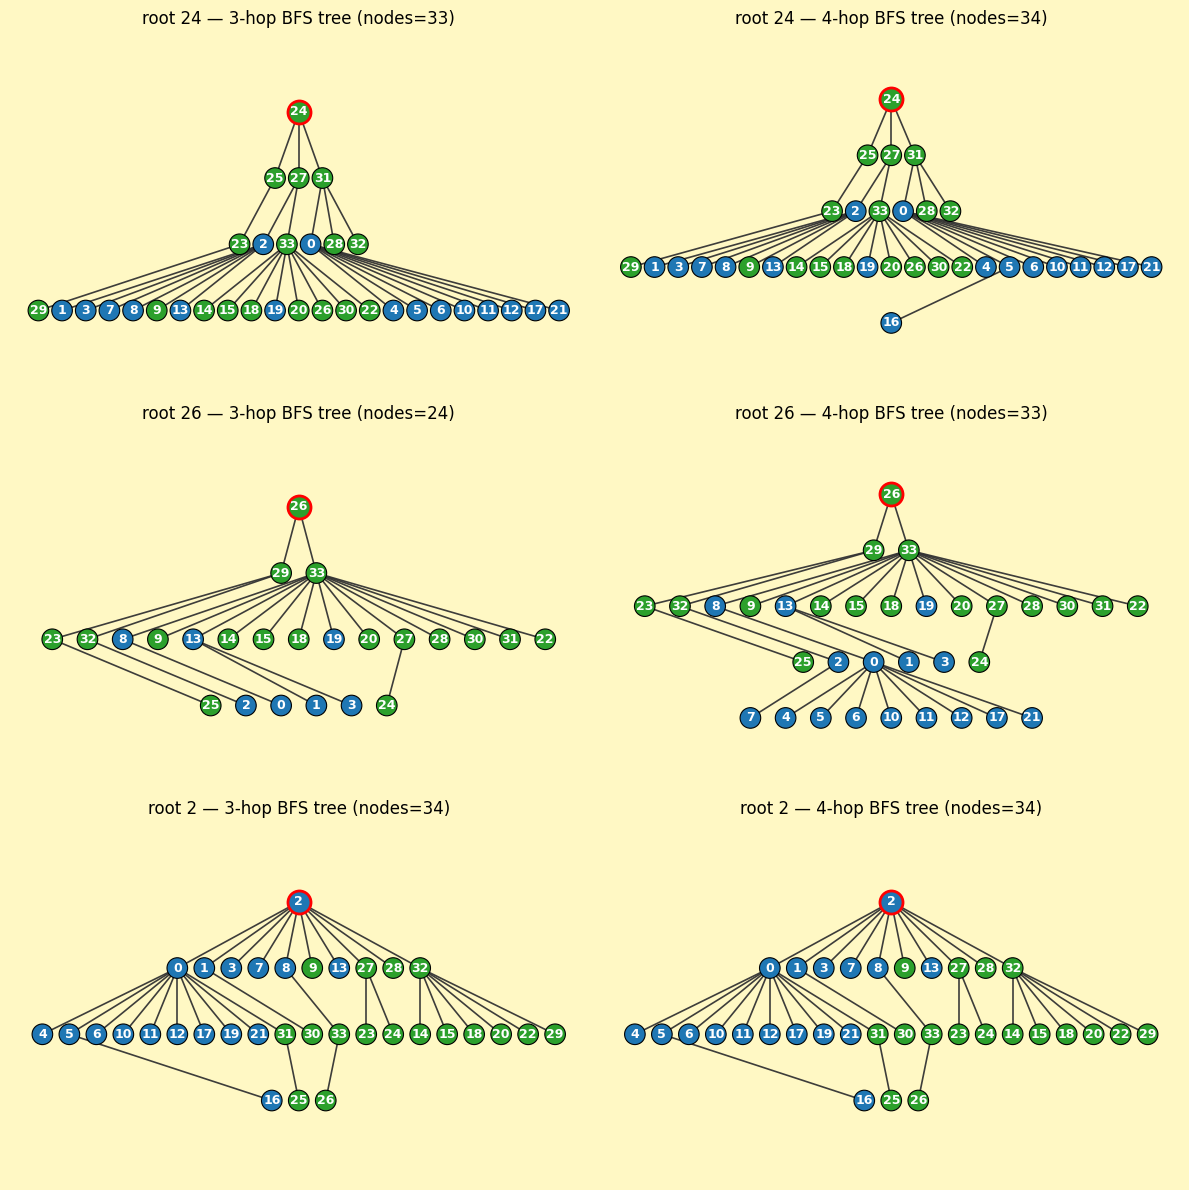

root depth | tree_nodes | induced_nodes | coverage | removed_edges | triangles | avg_clust
  24     3 |         33 |            33 |     0.97 |            44 |        44 | 0.568
  24     4 |         34 |            34 |     1.00 |            45 |        45 | 0.571
  26     3 |         24 |            24 |     0.71 |            34 |        31 | 0.531
  26     4 |         33 |            33 |     0.97 |            44 |        44 | 0.568
   2     3 |         34 |            34 |     1.00 |            45 |        45 | 0.571
   2     4 |         34 |            34 |     1.00 |            45 |        45 | 0.571


In [ ]:
picked  = random.sample(sorted(G.nodes()), 3)
depths  = (3, 4)
FIG_FACE, AX_FACE = "#fff8c4", "#fffde7"
BASE_NODE_SIZE, ROOT_SCALE = 220, 1.25
X_SPACING, Y_SPACING = 1.2, 1.6

rows = []

fig, axs = plt.subplots(len(picked), len(depths), figsize=(12, 4*len(picked)))
fig.patch.set_facecolor(FIG_FACE)
axs = np.atleast_2d(axs)

for i, root in enumerate(picked):
    for j, d in enumerate(depths):
        ax = axs[i, j]
        ax.set_facecolor(AX_FACE)
        for s in ax.spines.values():
            s.set_visible(True); s.set_edgecolor("#e0e0e0"); s.set_linewidth(1.0)

        T, level = bfs_tree_using_nx(G, root, depth=d)
        pos = tree_pos_by_level(level, X_SPACING, Y_SPACING)

        nodes_k  = set(level)
        induced  = G.subgraph(nodes_k)
        metrics  = (
            root, d, T.number_of_nodes(), induced.number_of_nodes(),
            induced.number_of_nodes()/G.number_of_nodes(),
            induced.number_of_edges() - T.number_of_edges(),
            sum(nx.triangles(induced).values())//3,
            round(nx.average_clustering(induced) if induced.number_of_nodes() else 0.0, 3)
        )
        rows.append(metrics)

        e = nx.draw_networkx_edges(T, pos, ax=ax, width=1.2, edge_color='#333333', alpha=0.95); _unclipped(e)
        node_list = list(T.nodes())
        node_colors = [color_map.get(G.nodes[n].get('club',''), "#888888") for n in node_list]
        ncoll = nx.draw_networkx_nodes(T, pos, nodelist=node_list, node_color=node_colors,
                                       node_size=BASE_NODE_SIZE, edgecolors='black', linewidths=0.8, ax=ax); _unclipped(ncoll)
        rcoll = nx.draw_networkx_nodes(T, pos, nodelist=[root],
                                       node_color=[color_map.get(G.nodes[root].get('club',''), "#888888")],
                                       node_size=BASE_NODE_SIZE*ROOT_SCALE, edgecolors='red', linewidths=2.0, ax=ax); _unclipped(rcoll)
        txt = nx.draw_networkx_labels(T, pos, labels={n:str(n) for n in node_list},
                                      font_size=9, font_weight='bold', font_color='white', ax=ax); _unclipped(txt)

        xs, ys = zip(*pos.values())
        pad_x, pad_y = max(1.2*X_SPACING, 0.6), max(1.2*Y_SPACING, 0.6)
        ax.set_xlim(min(xs)-pad_x, max(xs)+pad_x); ax.set_ylim(min(ys)-pad_y, max(ys)+pad_y)
        ax.set_title(f"root {root} — {d}-hop BFS tree (nodes={T.number_of_nodes()})")
        ax.axis('off')

plt.tight_layout(); plt.show()

print("root depth | tree_nodes | induced_nodes | coverage | removed_edges | triangles | avg_clust")
for r in rows:
    print(f"{r[0]:>4} {r[1]:>5} | {r[2]:10d} | {r[3]:13d} | {r[4]:8.2f} | {r[5]:13d} | {r[6]:9d} | {r[7]:.3f}")
